# Methods — elastic band validation and stiffness mimicking

Validates the VMC stiffness composition model against TPU elastic-band ground truth, comparing fixed $K_d$ and instantaneous gradient-descent tracking strategies.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from glob import glob
from mpl_toolkits.mplot3d import Axes3D

sys.path.insert(0, os.path.join('..'))
plt.style.use(os.path.join('..', 'plot_config.mplstyle'))

os.makedirs('outputs', exist_ok=True)

N_PTS    = 200   # common displacement grid size
DEG_POLY = 10    # polynomial degree for F(d) fitting


def interp_phase(dfs, phase, col='Force_N', n_pts=N_PTS):
    """Interpolate one phase across runs onto a common displacement grid."""
    pairs = []
    for df in dfs:
        if 'Phase' in df.columns:
            phase_df = df[df['Phase'] == phase].copy()
        else:
            phase_df = df.copy()

        if phase_df.empty:
            continue

        phase_df = phase_df.sort_values('UR5_displacement_m')
        grouped = phase_df.groupby('UR5_displacement_m', as_index=False)[col].mean()

        d = grouped['UR5_displacement_m'].to_numpy()
        f = grouped[col].to_numpy()
        if len(d) < 2:
            continue

        pairs.append((d, f))

    if not pairs:
        return None, None

    d_max = min(0.02, min(p[0].max() for p in pairs))
    grid  = np.linspace(0, d_max, n_pts)
    vals  = np.array([np.interp(grid, d, f) for d, f in pairs])
    return grid, vals


def poly_diff(f, d, deg=DEG_POLY):
    """Fit a degree-deg polynomial to F(d) and return its analytical derivative dF/dd."""
    coeffs = np.polyfit(d, f, deg)
    return np.polyval(np.polyder(coeffs), d)


## $K_x(K_d)$ from PassiveCompliance

In [10]:
PC_DIR = os.path.join('..', 'PassiveCompliance', 'Finger', 'outputs', 'stiffness_range')


def parse_pc_ks():
    ks = set()
    for f in glob(os.path.join(PC_DIR, 'K_*_run_*.csv')):
        stem = os.path.basename(f).split('_run_')[0]
        try:
            ks.add(float(stem[2:]))
        except ValueError:
            pass
    return sorted(ks)


def load_pc(k):
    files = sorted(glob(os.path.join(PC_DIR, f'K_{k:.2f}_run_*.csv')))
    return [pd.read_csv(f) for f in files]


pc_ks = parse_pc_ks()
print(f'PassiveCompliance K values: {pc_ks}')

# For each K_d: per-run poly-diff, clip to >=0, mean over displacement -> one K_x scalar
K_d_vals       = []
kx_overall     = []
kx_overall_std = []

for k in pc_ks:
    d, vals = interp_phase(load_pc(k), 'descent')
    if d is None:
        continue
    kx_runs = np.array([np.maximum(poly_diff(v, d), 0) for v in vals])
    kx_per_run = kx_runs.mean(axis=1)
    kx_overall.append(kx_per_run.mean())
    kx_overall_std.append(kx_per_run.std())
    K_d_vals.append(k)

K_d_vals       = np.array(K_d_vals)
kx_overall     = np.array(kx_overall)
kx_overall_std = np.array(kx_overall_std)

# Keep K_d sorted for piecewise-linear interpolation
order = np.argsort(K_d_vals)
K_d_vals = K_d_vals[order]
kx_overall = kx_overall[order]
kx_overall_std = kx_overall_std[order]

print(f'K_d_vals:  {K_d_vals}')
print(f'K_x overall: {kx_overall}')

# Piecewise-linear K_x(K_d) model
K_d_fine = np.linspace(K_d_vals.min(), K_d_vals.max(), 1000)
kx_piecewise = np.interp(K_d_fine, K_d_vals, kx_overall)


def kx_from_kd(kd):
    return np.interp(kd, K_d_vals, kx_overall)


def infer_kd_from_kx(kx_target):
    idx = np.argmin(np.abs(kx_piecewise - kx_target))
    return K_d_fine[idx]


PassiveCompliance K values: [0.02, 0.03, 0.05, 0.08, 0.13, 0.2, 0.28, 0.37, 0.48, 0.6]
K_d_vals:  [0.02 0.03 0.05 0.08 0.13 0.2  0.28 0.37 0.48 0.6 ]
K_x overall: [ 35.36834043  49.29645087  44.78159771  68.81387646 132.48238122
 186.8981858  199.51435472 211.11924761 211.36927501 218.28618349]


## Identify $K_d$

soft: 5 runs loaded
hard: 5 runs loaded
soft: K_x = 55.6 ± 1.0 N/m  |  K_d = 0.0635 ± 0.0012 N·m/rad
hard: K_x = 81.9 ± 1.3 N/m  |  K_d = 0.0903 ± 0.0010 N·m/rad
Saved identified K_d: {'soft': 0.06354354354354354, 'hard': 0.09025025025025024}
mimic soft: K_x = 64.0 ± 3.7 N/m
mimic hard: K_x = 95.0 ± 4.1 N/m


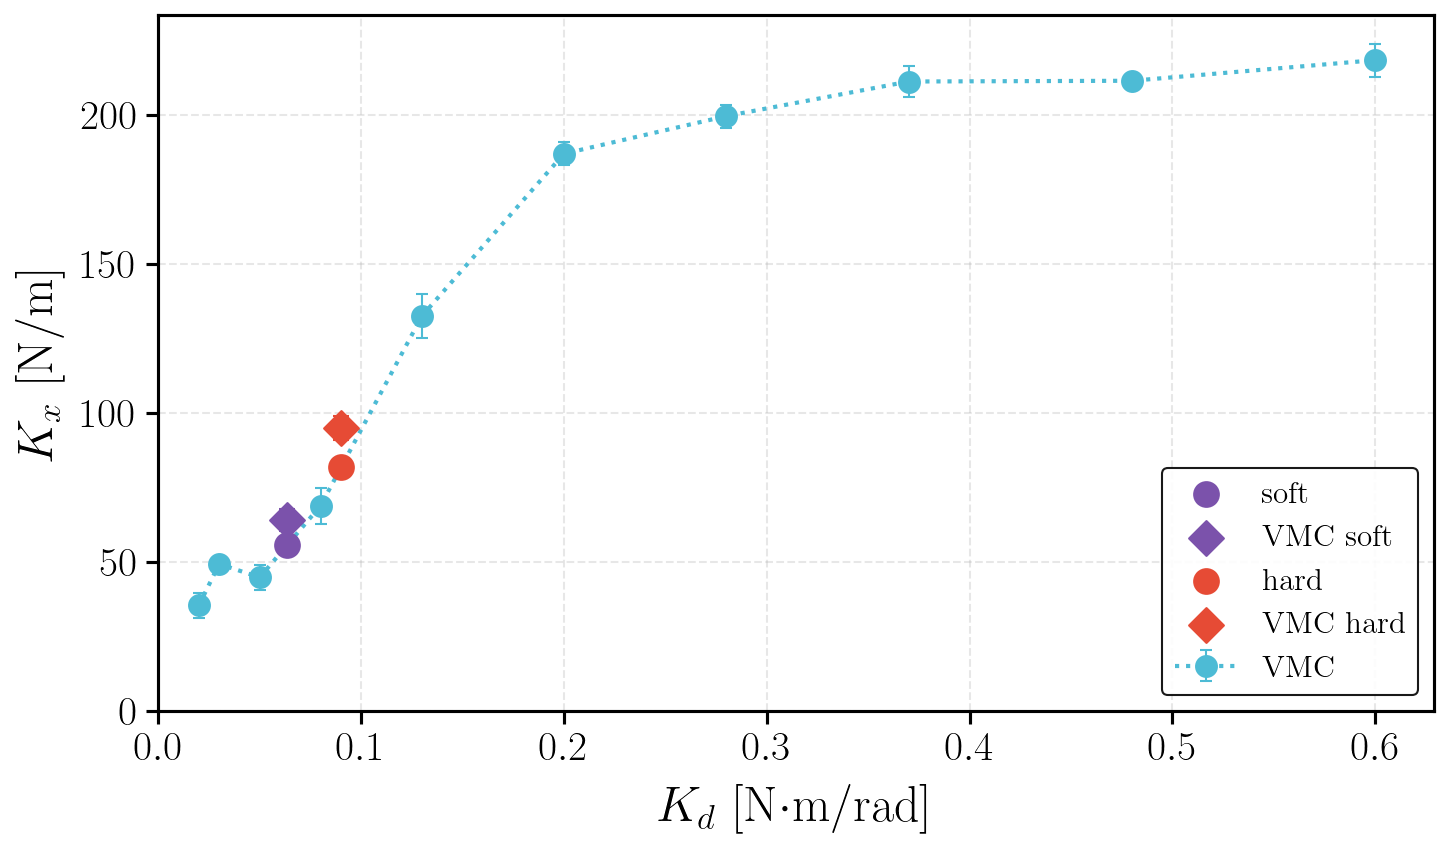

In [11]:
import json

COLORS = {'soft': '#7B52AB', 'hard': '#E64B35'}
MIMIC_DIR = os.path.join('outputs', 'mimic_springs')
os.makedirs(MIMIC_DIR, exist_ok=True)

def load_mimic(k):
    files = sorted(glob(os.path.join(MIMIC_DIR, f'K_{k:.4f}', f'K_{k:.4f}_run_*.csv')))
    return [pd.read_csv(f) for f in files]

eb_runs_all = {}
for spring in ('soft', 'hard'):
    files = sorted(glob(os.path.join('outputs', 'elastic_band', f'elastic_band_{spring}_run_*.csv')))
    if files:
        eb_runs_all[spring] = [pd.read_csv(f) for f in files]
        print(f'{spring}: {len(eb_runs_all[spring])} runs loaded')
    else:
        print(f'{spring}: no data found')

results = {}

for spring, eb_runs in eb_runs_all.items():
    d_eb, eb_vals = interp_phase(eb_runs, 'descent')
    if d_eb is None:
        continue

    kx_el_runs = []
    kd_inferred = []

    for v in eb_vals:
        kx_el_overall = np.maximum(poly_diff(v, d_eb), 0).mean()
        kx_el_runs.append(kx_el_overall)
        kd_inferred.append(infer_kd_from_kx(kx_el_overall))

    kx_el_runs = np.array(kx_el_runs)
    kd_inferred = np.array(kd_inferred)

    results[spring] = dict(
        kx_mean=float(kx_el_runs.mean()),
        kx_std=float(kx_el_runs.std()),
        kd_mean=float(kd_inferred.mean()),
        kd_std=float(kd_inferred.std()),
    )

    print(f"{spring}: K_x = {kx_el_runs.mean():.1f} ± {kx_el_runs.std():.1f} N/m  |  "
          f"K_d = {kd_inferred.mean():.4f} ± {kd_inferred.std():.4f} N·m/rad")

kd_export = {spring: res['kd_mean'] for spring, res in results.items()}
with open(os.path.join('outputs', 'mimic_springs', 'identified_kd.json'), 'w') as f:
    json.dump(kd_export, f, indent=2)
print(f'Saved identified K_d: {kd_export}')

# Compute K_x from mimic runs at the identified K_d (if data exists)
mimic_kx = {}
for spring, res in results.items():
    runs = load_mimic(res['kd_mean'])
    if not runs:
        continue
    d_m, m_vals = interp_phase(runs, 'descent')
    if d_m is None:
        continue
    kx_runs = np.array([np.maximum(poly_diff(v, d_m), 0).mean() for v in m_vals])
    mimic_kx[spring] = dict(kx_mean=float(kx_runs.mean()), kx_std=float(kx_runs.std()))
    print(f'mimic {spring}: K_x = {kx_runs.mean():.1f} ± {kx_runs.std():.1f} N/m')

fig, ax = plt.subplots()
ax.errorbar(
    K_d_vals, kx_overall, yerr=kx_overall_std, fmt='o', linestyle=':',
    color='#4DBBD5', ecolor='#4DBBD5', elinewidth=1.0, capsize=3,
    linewidth=2.0, zorder=5, label='VMC'
)

for spring, res in results.items():
    color = COLORS[spring]
    ax.errorbar(
        res['kd_mean'], res['kx_mean'],
        xerr=res['kd_std'], yerr=res['kx_std'],
        fmt='none', ecolor=color, elinewidth=1.2, capsize=4, zorder=6
    )
    ax.scatter(res['kd_mean'], res['kx_mean'], color=color, s=140, zorder=7, label=spring)

    if spring in mimic_kx:
        mx = mimic_kx[spring]
        ax.errorbar(res['kd_mean'], mx['kx_mean'], yerr=mx['kx_std'],
                    fmt='none', ecolor=color, elinewidth=1.2, capsize=4, zorder=8)
        ax.scatter(res['kd_mean'], mx['kx_mean'], color=color, s=140,
                   marker='D', zorder=9, label=f'VMC {spring}')

ax.set_xlabel(r'$K_d$ [N$\cdot$m/rad]')
ax.set_ylabel(r'$K_x$ [N/m]')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(loc='lower right', fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'mimic_springs', 'Kx_identification.pdf'), bbox_inches='tight')
plt.show()

## $F$–$d$ comparison

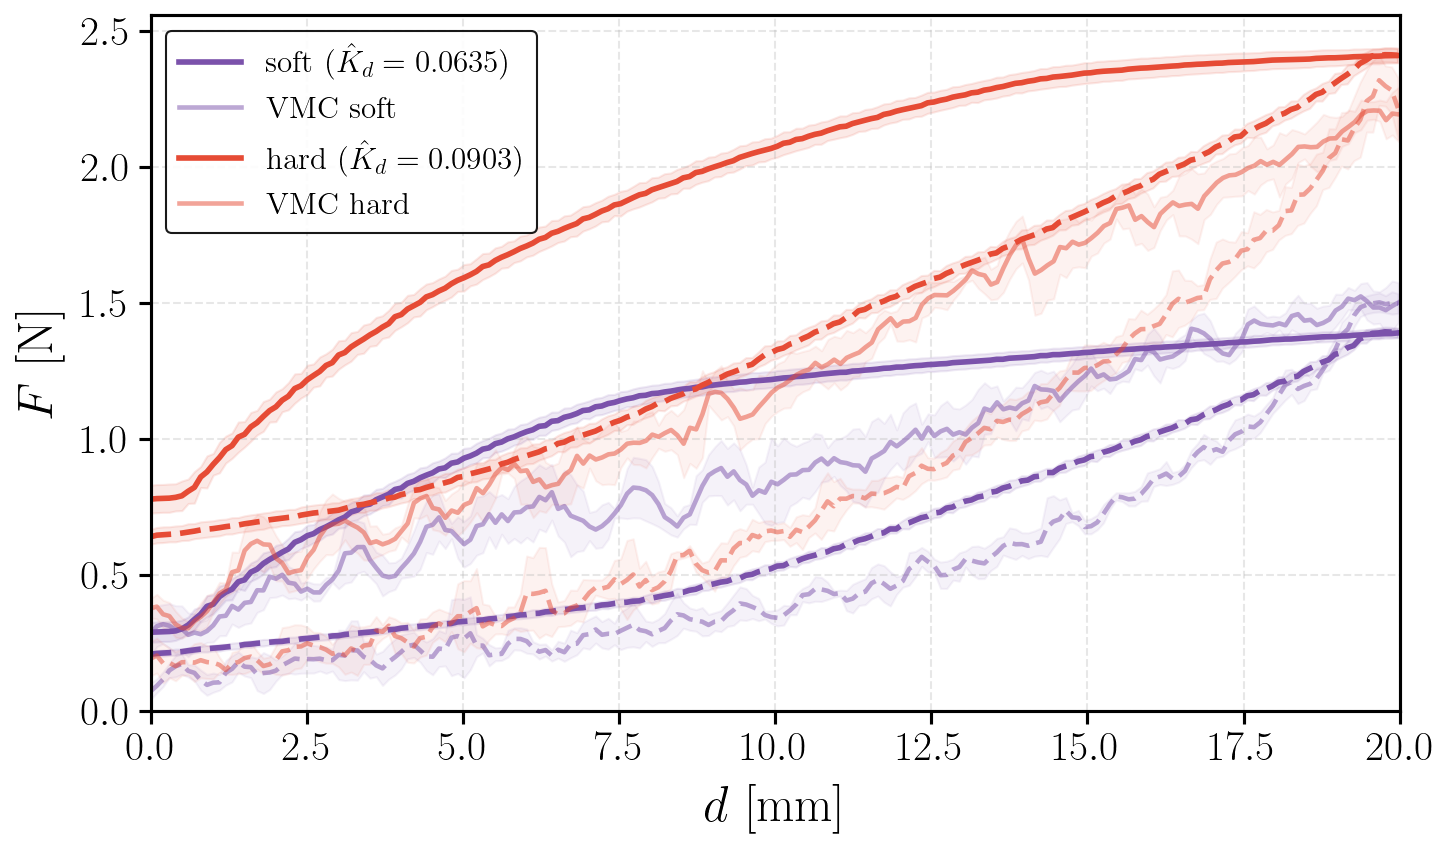

In [12]:
phase_specs = [('descent', '-'), ('ascent', '--')]

fig, ax = plt.subplots()

for spring, eb_runs in eb_runs_all.items():
    kd = results[spring]['kd_mean']
    kd_txt = f'{kd:.4f}'
    mimic_runs = load_mimic(kd)

    if not mimic_runs:
        print(f'WARNING: no mimic data for {spring} (K_d={kd_txt}) — run 20mm_mimic_real_springs.py first')

    for phase, linestyle in phase_specs:
        d, vals = interp_phase(eb_runs, phase=phase, col='Force_N')
        if vals is not None:
            d_mm = d * 1e3
            mean, std = vals.mean(0), vals.std(0)
            ax.plot(d_mm, mean, color=COLORS[spring], linewidth=2.7, linestyle=linestyle,
                    label=rf'{spring} ($\hat{{K}}_d={kd_txt}$)' if phase == 'descent' else None)
            ax.fill_between(d_mm, mean - std, mean + std, color=COLORS[spring], alpha=0.12)

        if mimic_runs:
            d_m, m_vals = interp_phase(mimic_runs, phase=phase, col='Force_N')
            if d_m is not None:
                d_mm = d_m * 1e3
                mean, std = m_vals.mean(0), m_vals.std(0)
                ax.plot(d_mm, mean, color=COLORS[spring], linewidth=2.2, linestyle=linestyle,
                        alpha=0.5, label=rf'VMC {spring}' if phase == 'descent' else None)
                ax.fill_between(d_mm, mean - std, mean + std, color=COLORS[spring], alpha=0.07)

ax.set_xlabel(r'$d$ [mm]')
ax.set_ylabel(r'$F$ [N]')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.legend(loc='upper left', fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'mimic_springs', 'elastic_band_Fvsd.pdf'), bbox_inches='tight')
plt.show()

## Instantaneous stiffness profile $K_x(d)$

Average $F$–$d$ per spring, spline-smoothed and differentiated to obtain $K_x(d) = \mathrm{d}F/\mathrm{d}d$. Saved to `outputs/data/{soft,hard}_stiffness_profile.csv`.

soft: saved outputs/data/soft_stiffness_profile.csv
hard: saved outputs/data/hard_stiffness_profile.csv


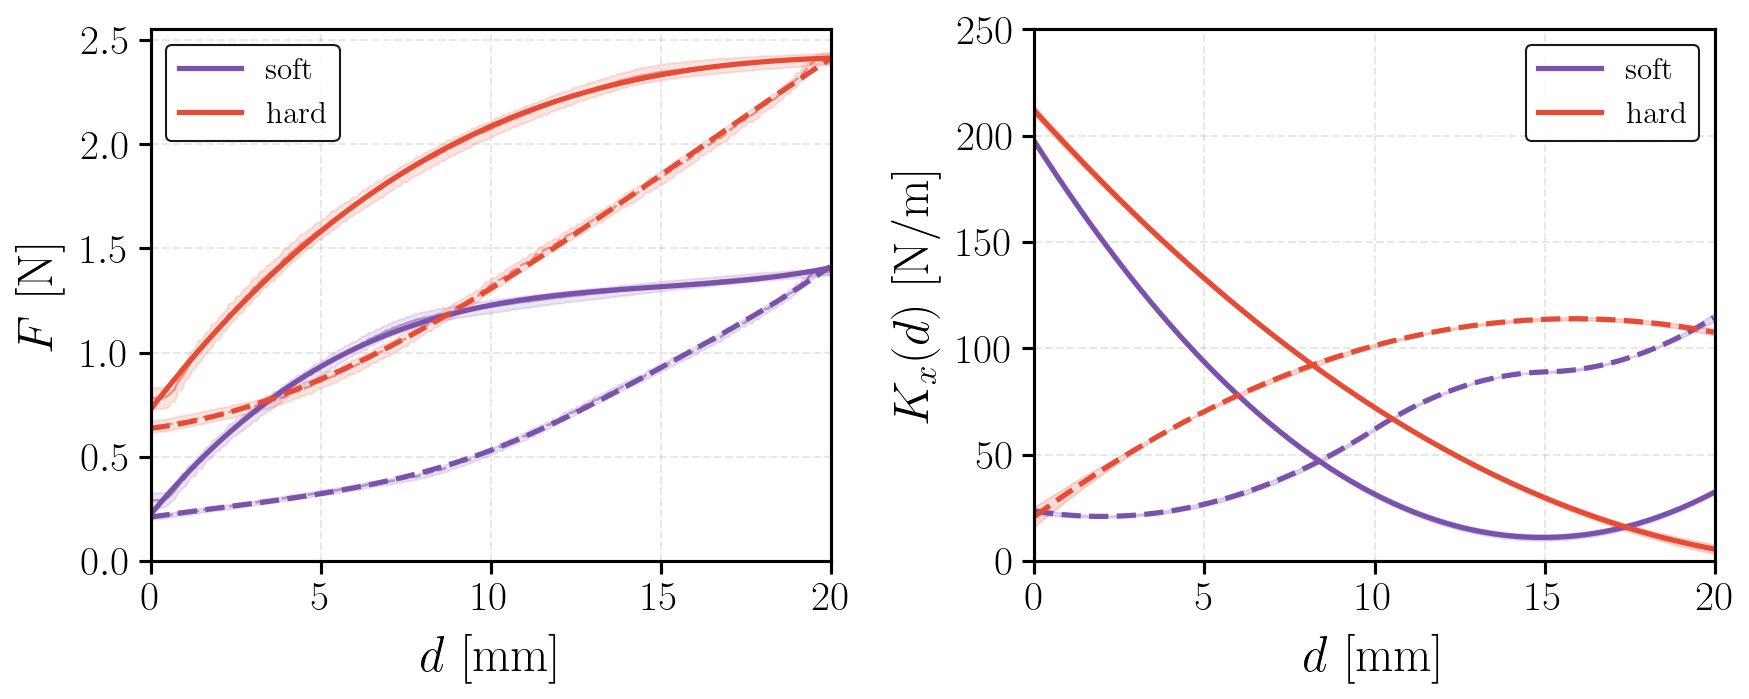

In [13]:
from scipy.interpolate import UnivariateSpline
from sklearn.isotonic import IsotonicRegression

DATA_DIR = os.path.join('outputs', 'data')
os.makedirs(DATA_DIR, exist_ok=True)

_ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
kx_profiles = {}

fig, (ax_f, ax_k) = plt.subplots(1, 2, figsize=(12, 5))

for spring, eb_runs in eb_runs_all.items():
    color  = COLORS[spring]
    frames = []

    for phase, ls in [('descent', '-'), ('ascent', '--')]:
        d_grid, vals = interp_phase(eb_runs, phase)
        if d_grid is None:
            print(f'{spring} {phase}: no data')
            continue

        f_mean = vals.mean(axis=0)
        f_std  = vals.std(axis=0)
        n_runs = vals.shape[0]
        sigma  = (f_std / np.sqrt(n_runs)).mean()
        s      = len(d_grid) * sigma ** 2

        spl     = UnivariateSpline(d_grid, _ir.fit_transform(d_grid, f_mean), k=3, s=s)
        kx_mean = np.maximum(spl.derivative()(d_grid), 0.0)

        kx_runs = np.array([
            np.maximum(UnivariateSpline(d_grid, _ir.fit_transform(d_grid, v), k=3, s=s).derivative()(d_grid), 0.0)
            for v in vals
        ])
        kx_std = kx_runs.std(axis=0)

        kx_profiles[(spring, phase)] = (d_grid, kx_mean)
        frames.append(pd.DataFrame({'Phase': phase, 'displacement_m': d_grid, 'Kx_N_per_m': kx_mean, 'F_N': spl(d_grid)}))

        d_mm  = d_grid * 1e3
        label = spring if phase == 'descent' else None

        ax_f.fill_between(d_mm, f_mean - f_std, f_mean + f_std, color=color, alpha=0.15)
        ax_f.plot(d_mm, f_mean,      color=color, linewidth=1.2, linestyle=ls, alpha=0.55)
        ax_f.plot(d_mm, spl(d_grid), color=color, linewidth=2.5, linestyle=ls, label=label)

        ax_k.fill_between(d_mm, np.maximum(kx_mean - kx_std, 0), kx_mean + kx_std,
                          color=color, alpha=0.2)
        ax_k.plot(d_mm, kx_mean, color=color, linewidth=2.5, linestyle=ls, label=label)

    if frames:
        fpath = os.path.join(DATA_DIR, f'{spring}_stiffness_profile.csv')
        pd.concat(frames, ignore_index=True).to_csv(fpath, index=False)
        print(f'{spring}: saved {fpath}')

ax_f.set_xlabel(r'$d$ [mm]')
ax_f.set_ylabel(r'$F$ [N]')
ax_f.set_xlim(0, 20)
ax_f.set_ylim(bottom=0)
ax_f.legend(fontsize='small')

ax_k.set_xlabel(r'$d$ [mm]')
ax_k.set_ylabel(r'$K_x(d)$ [N/m]')
ax_k.set_xlim(0, 20)
ax_k.set_ylim(0, 250)
ax_k.legend(fontsize='small')

plt.tight_layout()
plt.savefig(os.path.join('outputs', 'data', 'kx_profile.pdf'), bbox_inches='tight')
plt.show()


## $F$–$d$: TPU vs instantaneous stiffness tracking

Ground truth vs VMC feed-forward stiffness tracking (`outputs/instant_mimic_springs/`). Solid = descent, dashed = ascent.

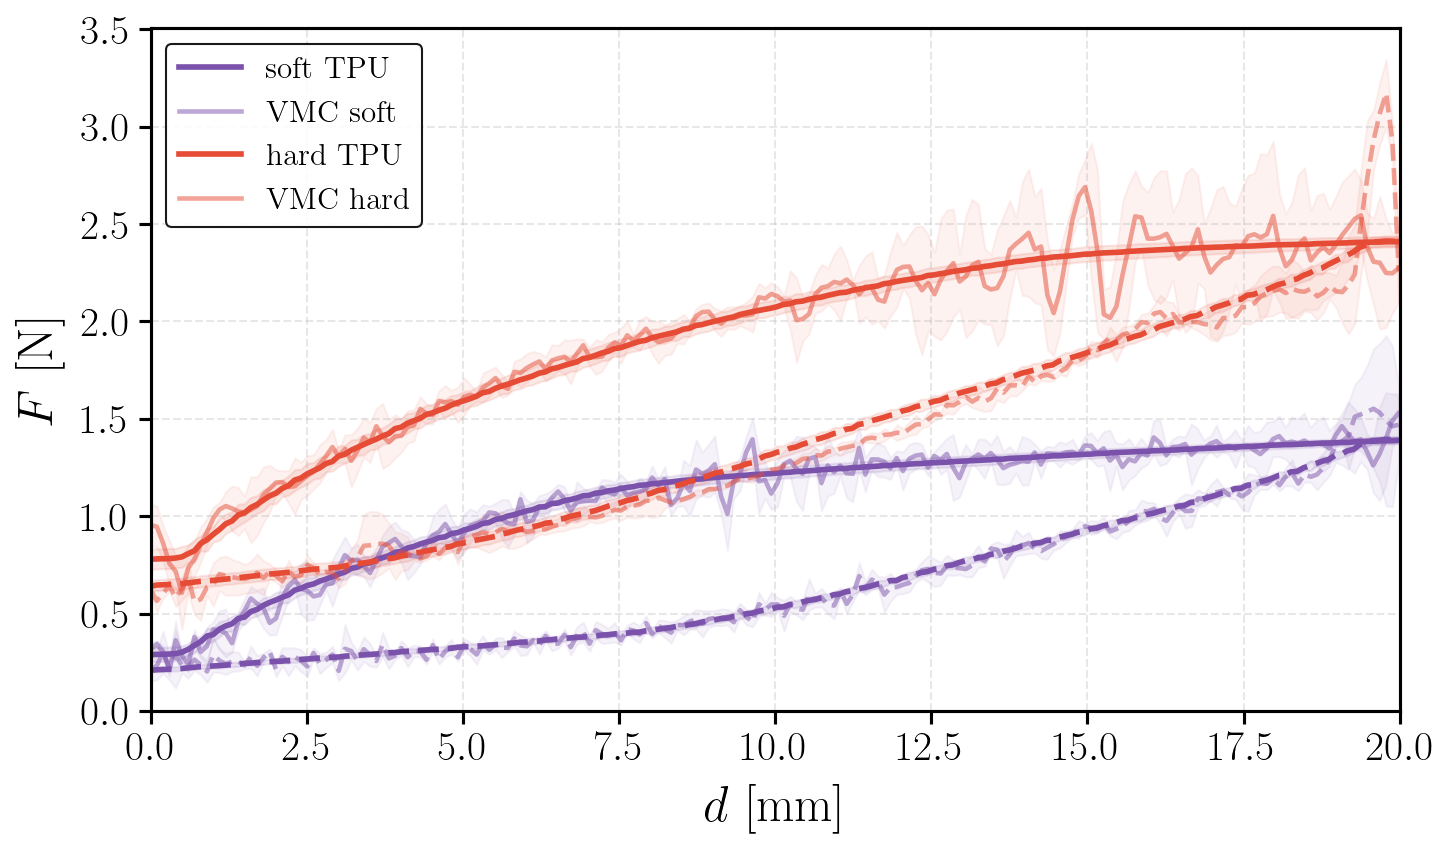

In [14]:
INSTANT_DIR = os.path.join('outputs', 'instant_mimic_springs')

def load_instant(profile):
    files = sorted(glob(os.path.join(INSTANT_DIR, profile, f'{profile}_run_*.csv')))
    return [pd.read_csv(f) for f in files]

phase_specs = [('descent', '-'), ('ascent', '--')]

fig, ax = plt.subplots()

for spring, eb_runs in eb_runs_all.items():
    instant_runs = load_instant(spring)

    if not instant_runs:
        print(f'WARNING: no instant mimic data for {spring} — run instant_mimic_real_springs.py')

    for phase, linestyle in phase_specs:
        d, vals = interp_phase(eb_runs, phase=phase, col='Force_N')
        if vals is not None:
            d_mm = d * 1e3
            mean, std = vals.mean(0), vals.std(0)
            ax.plot(d_mm, mean, color=COLORS[spring], linewidth=2.7, linestyle=linestyle,
                    label=rf'{spring} TPU' if phase == 'descent' else None)
            ax.fill_between(d_mm, mean - std, mean + std, color=COLORS[spring], alpha=0.12)

        if instant_runs:
            d_m, m_vals = interp_phase(instant_runs, phase=phase, col='Force_N')
            if d_m is not None:
                d_mm = d_m * 1e3
                mean, std = m_vals.mean(0), m_vals.std(0)
                ax.plot(d_mm, mean, color=COLORS[spring], linewidth=2.2, linestyle=linestyle,
                        alpha=0.5, label=rf'VMC {spring}' if phase == 'descent' else None)
                ax.fill_between(d_mm, mean - std, mean + std, color=COLORS[spring], alpha=0.07)

ax.set_xlabel(r'$d$ [mm]')
ax.set_ylabel(r'$F$ [N]')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.legend(loc='upper left', fontsize='small')
plt.tight_layout()
os.makedirs(os.path.join('outputs', 'instant_mimic_springs'), exist_ok=True)
plt.savefig(os.path.join('outputs', 'instant_mimic_springs', 'instant_Fvsd.pdf'), bbox_inches='tight')
plt.show()


## $F$–$d$ and $K_x(d)$: TPU vs VMC instant mimic

Per-phase comparison: thick = TPU ground truth, thin = VMC instant mimic.

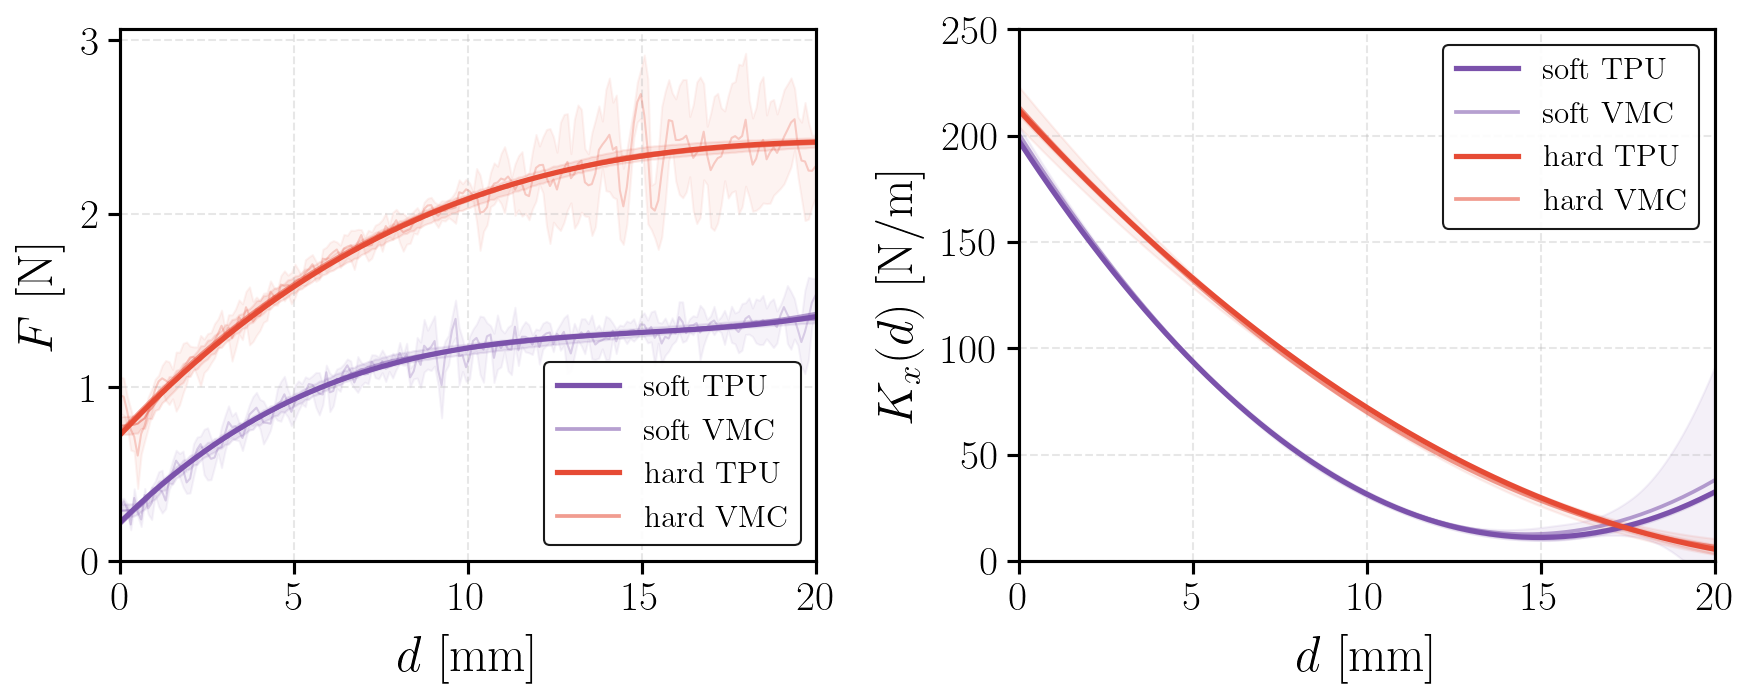

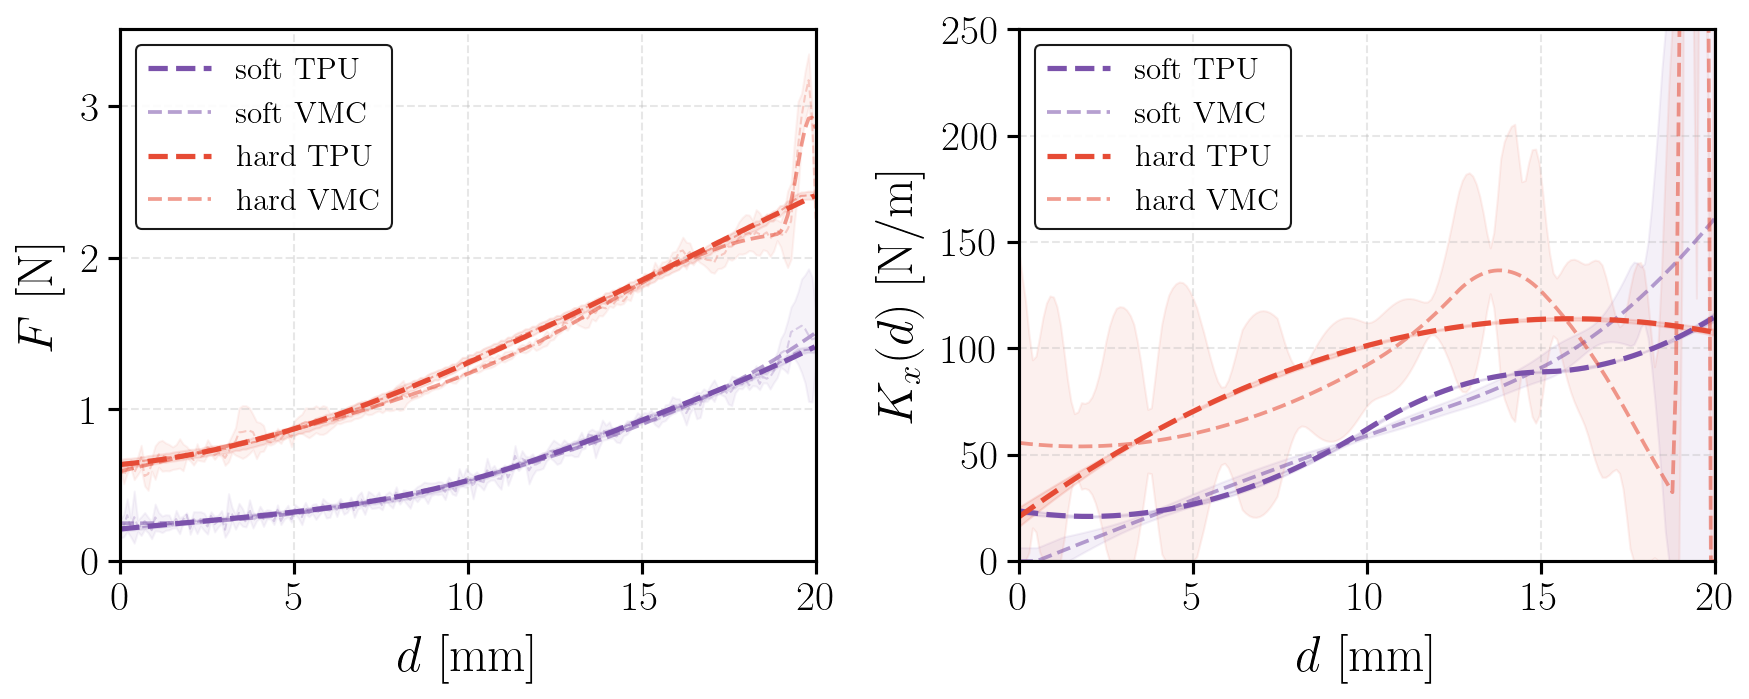

In [15]:
for phase, ls in [('descent', '-'), ('ascent', '--')]:
    fig, (ax_f, ax_k) = plt.subplots(1, 2, figsize=(12, 5))

    for spring, eb_runs in eb_runs_all.items():
        color        = COLORS[spring]
        instant_runs = load_instant(spring)

        if not instant_runs:
            print(f'WARNING: no instant mimic data for {spring} — run instant_mimic_real_springs.py')

        for runs, lbl_sfx, lw, alpha in [
            (eb_runs,      'TPU', 2.5, 1.00),
            (instant_runs, 'VMC', 1.8, 0.55),
        ]:
            if not runs:
                continue

            d_grid, vals = interp_phase(runs, phase)
            if d_grid is None:
                continue

            f_mean = vals.mean(axis=0)
            f_std  = vals.std(axis=0)
            n_runs = vals.shape[0]
            sigma  = (f_std / np.sqrt(n_runs)).mean()
            s      = len(d_grid) * sigma ** 2

            spl     = UnivariateSpline(d_grid, _ir.fit_transform(d_grid, f_mean), k=3, s=s)
            kx_mean = np.maximum(spl.derivative()(d_grid), 0.0)

            kx_runs = np.array([
                np.maximum(UnivariateSpline(d_grid, _ir.fit_transform(d_grid, v), k=3, s=s).derivative()(d_grid), 0.0)
                for v in vals
            ])
            kx_std = kx_runs.std(axis=0)

            d_mm  = d_grid * 1e3
            label = f'{spring} {lbl_sfx}'

            ax_f.fill_between(d_mm, f_mean - f_std, f_mean + f_std, color=color, alpha=0.12 * alpha)
            ax_f.plot(d_mm, f_mean,      color=color, linewidth=1.0, linestyle=ls, alpha=0.45 * alpha)
            ax_f.plot(d_mm, spl(d_grid), color=color, linewidth=lw,  linestyle=ls, alpha=alpha, label=label)

            ax_k.fill_between(d_mm, np.maximum(kx_mean - kx_std, 0), np.minimum(kx_mean + kx_std, 250),
                              color=color, alpha=0.15 * alpha)
            ax_k.plot(d_mm, kx_mean, color=color, linewidth=lw, linestyle=ls, alpha=alpha, label=label)

    ax_f.set_xlabel(r'$d$ [mm]')
    ax_f.set_ylabel(r'$F$ [N]')
    ax_f.set_xlim(0, 20)
    ax_f.set_ylim(bottom=0)
    ax_f.legend(fontsize='small')

    ax_k.set_xlabel(r'$d$ [mm]')
    ax_k.set_ylabel(r'$K_x(d)$ [N/m]')
    ax_k.set_xlim(0, 20)
    ax_k.set_ylim(0, 250)
    ax_k.legend(fontsize='small')

    plt.tight_layout()
    os.makedirs(os.path.join('outputs', 'instant_mimic_springs'), exist_ok=True)
    plt.savefig(os.path.join('outputs', 'instant_mimic_springs', f'instant_Fvsd_Kx_{phase}.pdf'), bbox_inches='tight')
    plt.show()


## $K_d(d)$: commanded stiffness trajectory

K_d equivalent of the instantaneous tip stiffness `K_des_N_per_m` logged at each sample, converted via the `infer_kd_from_kx` map. Shows what scalar VMC stiffness the feed-forward controller applies at each depth.

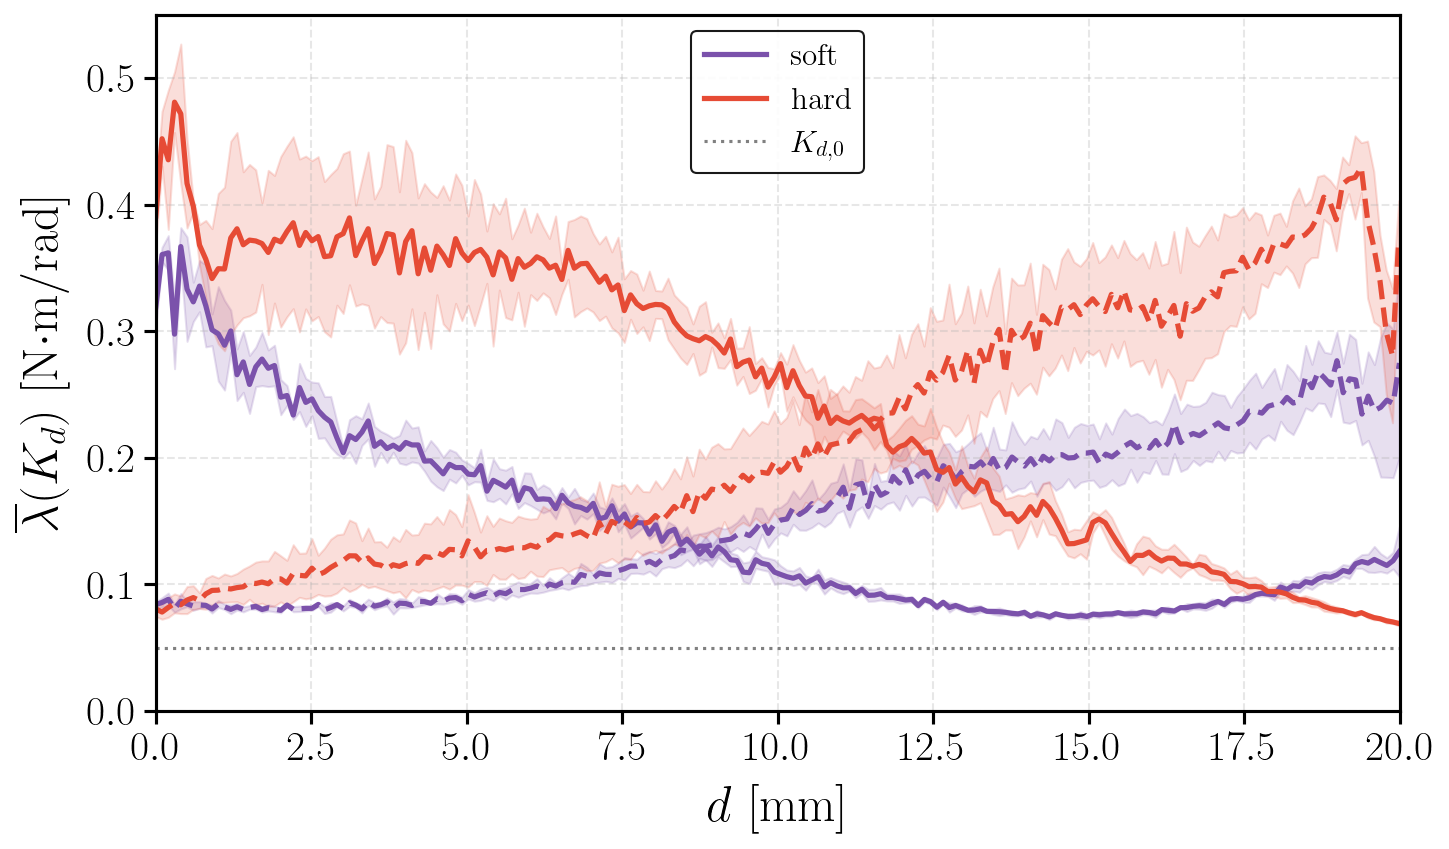

In [16]:
K_D0_VAL = 0.05  # mean eigenvalue of K_D0 = np.eye(3) * 0.05

fig, ax = plt.subplots()

for spring in ('soft', 'hard'):
    color        = COLORS[spring]
    instant_runs = load_instant(spring)

    if not instant_runs:
        print(f'WARNING: no instant mimic data for {spring}')
        continue

    for phase, ls in [('descent', '-'), ('ascent', '--')]:
        kd_list = []
        for df in instant_runs:
            phd = df[df['Phase'] == phase].sort_values('UR5_displacement_m')
            if phd.empty:
                continue
            d_arr = phd['UR5_displacement_m'].values
            # Mean eigenvalue of K_theta = trace/3 = mean of diagonal entries
            mean_eig = (phd['Kth_11'].values + phd['Kth_22'].values + phd['Kth_33'].values) / 3.0
            d_max  = min(0.02, d_arr.max())
            d_grid = np.linspace(0, d_max, N_PTS)
            kd_list.append(np.interp(d_grid, d_arr, mean_eig))

        if not kd_list:
            continue

        vals      = np.array(kd_list)
        mean, std = vals.mean(0), vals.std(0)
        d_mm      = d_grid * 1e3
        label     = spring if phase == 'descent' else None

        ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=ls, label=label)
        ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=0.18)

ax.axhline(K_D0_VAL, color='gray', linestyle=':', linewidth=1.5, label=r'$K_{d,0}$')
ax.set_xlabel(r'$d$ [mm]')
ax.set_ylabel(r'$\overline{\lambda}(K_d)$ [N$\cdot$m/rad]')
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.legend(fontsize='small')
plt.tight_layout()
plt.savefig(os.path.join('outputs', 'instant_mimic_springs', 'Kd_vs_d.pdf'), bbox_inches='tight')
plt.show()
